# Rare-event distributions

Work item 27 (`.claude/CLAUDE.md`) / plan `.claude/docs/plans/26-major-events-cataclysm.md` §10.

The test suite only ever answers "does this ever happen" (a pass/fail
check against a wide seed scan). This notebook looks at the actual
*shape* of four rare-event distributions across a batch of real
generated worlds — reading `--json` CLI output, no new Haskell-side
export needed.

Regenerate the dataset this notebook reads with:

```
cabal build exe:historian   # inside `nix develop`
notebooks/generate_dataset.sh [seeds] [steps]   # defaults: 1000 seeds, 60 steps
```

`notebooks/data/` is gitignored — regeneratable, not source.

In [1]:
import json
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data/runs.jsonl")
runs = [json.loads(line) for line in DATA.open()]
print(f"loaded {len(runs)} runs, {runs[0]['steps']} steps each")

loaded 1000 runs, 60 steps each


## 1. Cataclysm timing

Work item 26 §2's own question: do `Tuning`'s age/cult-count weight-
scaling constants actually keep the *ordinary* (non-guaranteed) chance
rare at typical run lengths? The guaranteed first-year-crossing firing
is not in question — invariant, always exactly one, always early — what
this section actually checks is what happens *after* that.

In [2]:
GENESIS_EPOCH = min(e["born"] for r in runs for e in r["world"]["entities"])

first_index, first_epoch_delta, cataclysm_counts = [], [], []
for r in runs:
    events = sorted(r["world"]["events"], key=lambda e: e["id"])
    cata = [e for e in events if e["kind"] == "cataclysm"]
    cataclysm_counts.append(len(cata))
    if cata:
        idx = next(i for i, e in enumerate(events) if e["id"] == cata[0]["id"])
        first_index.append(idx)
        first_epoch_delta.append(cata[0]["epoch"] - GENESIS_EPOCH)

df_cata = pd.DataFrame({"seed": [r["seed"] for r in runs], "cataclysm_count": cataclysm_counts})

print(f"guaranteed firing present in {len(first_index)}/{len(runs)} runs (should be all of them)")
print(f"runs with a second, ordinary-chance cataclysm within {runs[0]['steps']} steps: "
      f"{(df_cata.cataclysm_count >= 2).sum()}/{len(runs)} "
      f"({100 * (df_cata.cataclysm_count >= 2).mean():.1f}%)")
print(df_cata.cataclysm_count.describe())

guaranteed firing present in 1000/1000 runs (should be all of them)
runs with a second, ordinary-chance cataclysm within 60 steps: 761/1000 (76.1%)
count    1000.00000
mean       14.46500
std        22.11963
min         1.00000
25%         2.00000
50%         3.00000
75%         6.00000
max        60.00000
Name: cataclysm_count, dtype: float64


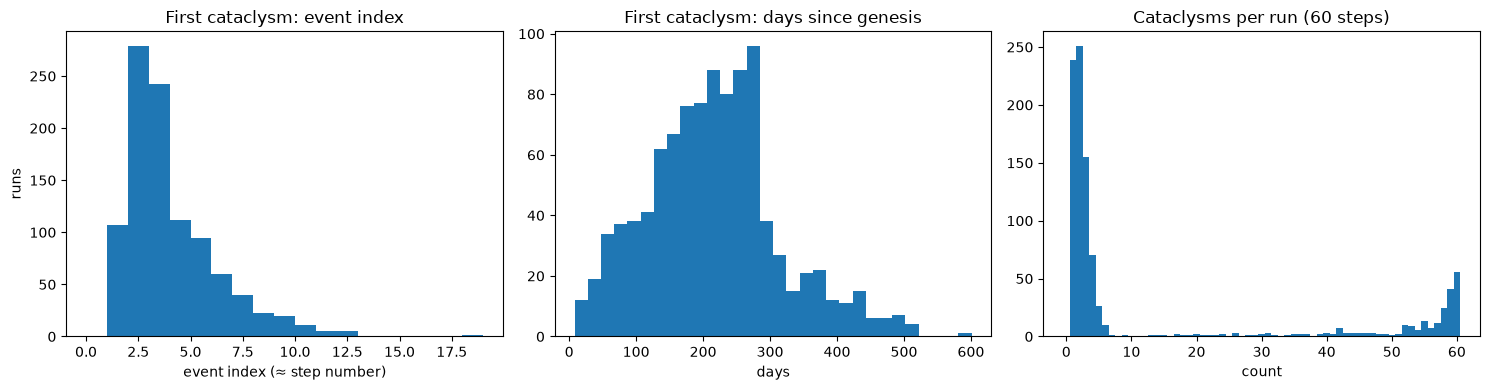

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(first_index, bins=range(0, max(first_index) + 2))
axes[0].set_title("First cataclysm: event index")
axes[0].set_xlabel("event index (≈ step number)")
axes[0].set_ylabel("runs")

axes[1].hist(first_epoch_delta, bins=30)
axes[1].set_title("First cataclysm: days since genesis")
axes[1].set_xlabel("days")

axes[2].hist(cataclysm_counts, bins=range(0, max(cataclysm_counts) + 2), align="left")
axes[2].set_title(f"Cataclysms per run ({runs[0]['steps']} steps)")
axes[2].set_xlabel("count")

fig.tight_layout()
plt.show()

**Reading this:** the first bar always fires within the first handful of
events — expected, that's the guaranteed one, anchored to the world's
first calendar year-boundary crossing, not a probabilistic outcome.
The third panel is the real answer to §2's question: how often does the
*ordinary* chance produce a second cataclysm within a 60-step run. If
that fraction looks too high for "rare, world-scale disaster," the
weight-scaling constants (`tnCataclysmBaseWeight`/`tnCataclysmYearsPerWeight`/
`tnCataclysmCultsPerWeight`/`tnCataclysmMaxWeight`) are the ones to
retune — the same way `rivalryRuleWeight` was tuned against a real
distribution in Decision 41.

## 2. Rivalry / trial-by-combat / coup frequency

Decision 41's own subject — `rivalryRuleWeight = 20` was tuned to stop
these being "the two rarest events" by dilution alone, not because
`Rivalry` itself is scarce. A real distribution, not just the test
suite's pass/fail scan.

In [4]:
tbc_counts, coup_counts = [], []
for r in runs:
    kinds = [e["kind"] for e in r["world"]["events"]]
    tbc_counts.append(kinds.count("trial-by-combat"))
    coup_counts.append(kinds.count("coup"))

df_riv = pd.DataFrame({"seed": [r["seed"] for r in runs], "trial_by_combat": tbc_counts, "coup": coup_counts})

print(f"trial by combat: {(df_riv.trial_by_combat > 0).sum()}/{len(runs)} runs have >=1, "
      f"{df_riv.trial_by_combat.sum()} events total")
print(f"coup: {(df_riv.coup > 0).sum()}/{len(runs)} runs have >=1, "
      f"{df_riv.coup.sum()} events total")

trial by combat: 5/1000 runs have >=1, 5 events total
coup: 4/1000 runs have >=1, 4 events total


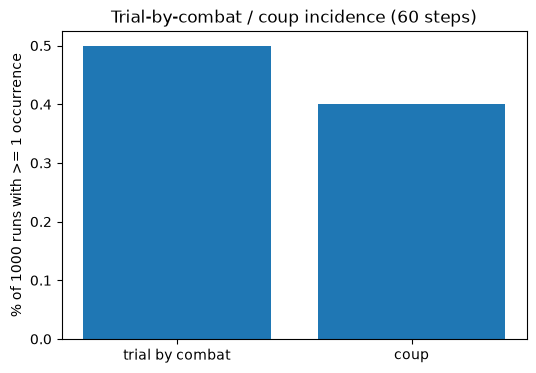

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["trial by combat", "coup"],
    [(df_riv.trial_by_combat > 0).mean() * 100, (df_riv.coup > 0).mean() * 100],
)
ax.set_ylabel(f"% of {len(runs)} runs with >= 1 occurrence")
ax.set_title(f"Trial-by-combat / coup incidence ({runs[0]['steps']} steps)")
plt.show()

**Reading this:** both are still genuinely rare in absolute terms over a
60-step run — `rivalryRuleWeight = 20` made them *reachable* (they used
to need an 11000-seed scan to find one instance at all), not common. If
this fraction ever looks implausibly low again after some future
unrelated RNG-cascade change, this is the plot to re-run before assuming
the rule itself regressed.

## 3. Prophecy fulfillment lag

Steps (in days) between a `Prophesied` fact and its matching `Fulfilled`
one — reconstructed from the wire format alone: a `Fulfilled` fact's
object points back at the prophecy's own event (`REvent`), and every
event carries its own epoch.

In [6]:
lags = []
for r in runs:
    events_by_id = {e["id"]: e for e in r["world"]["events"]}
    for f in r["world"]["facts"]:
        if f["predicate"] == "Fulfilled" and f["object"] and "event" in f["object"]:
            prophecy_event = events_by_id.get(f["object"]["event"])
            if prophecy_event:
                lags.append(f["epoch"] - prophecy_event["epoch"])

lags = np.array(lags)
print(f"{len(lags)} fulfillments found across {len(runs)} runs")
print(pd.Series(lags).describe())

2094 fulfillments found across 1000 runs
count    2094.000000
mean     1820.542502
std      1630.433516
min         3.000000
25%       512.250000
50%      1333.500000
75%      2699.000000
max      8535.000000
dtype: float64


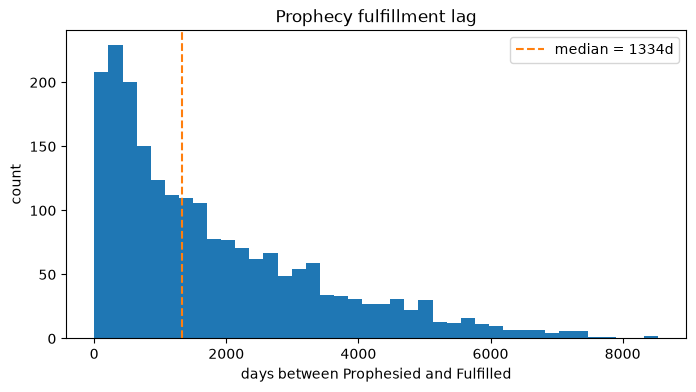

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lags, bins=40)
ax.set_xlabel("days between Prophesied and Fulfilled")
ax.set_ylabel("count")
ax.set_title("Prophecy fulfillment lag")
ax.axvline(np.median(lags), color="C1", linestyle="--", label=f"median = {np.median(lags):.0f}d")
ax.legend()
plt.show()

**Reading this:** a long right tail is expected — `fulfillProphecies`
scans every outcome's claims generically (invariant: no dedicated
"predicts a cataclysm" mechanic, per §6 of the cataclysm plan), so a
fulfillment can land whenever *any* rule's own ordinary firing happens to
produce the predicted predicate, not on any fixed schedule. Once a
cataclysm-caused incidental fulfillment is distinguishable on the wire
(it currently isn't — nothing marks *which* rule produced the fulfilling
claim), splitting this histogram by cause is a real follow-up, not
attempted here.

## 4. Backfill recursion depth

`Historian.World.weightedResolve`'s mutual recursion
(`backfillWard`/`backfillPatron`, Decision 28/32) was argued to be a
"provably terminating, subcritical branching process" analytically —
each hop only 15% likely to recurse at all. This checks that argument
against real generated worlds.

**Caveat, stated plainly:** the wire format has no explicit depth tag on
a backfill-produced `Venerates` claim, so this is a *proxy*, not exact
instrumentation — every `Venerates` claim attested by a `"backstory"`-
kind event is treated as one edge in an entity graph, and the reported
number is each connected component's size (entity count), not a true
recursion depth. A component of size 2 is one non-recursive bind (depth
1); a larger component is consistent with (but not proof of) deeper
recursion, since two *independent* depth-1 binds that happen to share an
entity would also merge into one component. Exact depth instrumentation
would need a new field on the wire — a real follow-up, not attempted
here.

In [8]:
component_sizes = []
for r in runs:
    backstory_ids = {e["id"] for e in r["world"]["events"] if e["kind"] == "backstory"}
    edges = [
        (f["subject"], f["object"]["entity"])
        for f in r["world"]["facts"]
        if f["source"] in backstory_ids and f["predicate"] == "Venerates" and f["object"] and "entity" in f["object"]
    ]
    if not edges:
        continue

    parent = {}

    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for a, b in edges:
        union(a, b)

    members = collections.defaultdict(set)
    for node in parent:
        members[find(node)].add(node)
    component_sizes.extend(len(m) for m in members.values())

component_sizes = np.array(component_sizes)
print(f"{len(component_sizes)} backstory-chain components across {len(runs)} runs")
print(pd.Series(component_sizes).describe())

2682 backstory-chain components across 1000 runs
count    2682.000000
mean        5.738255
std         4.267197
min         2.000000
25%         3.000000
50%         4.000000
75%         8.000000
max        25.000000
dtype: float64


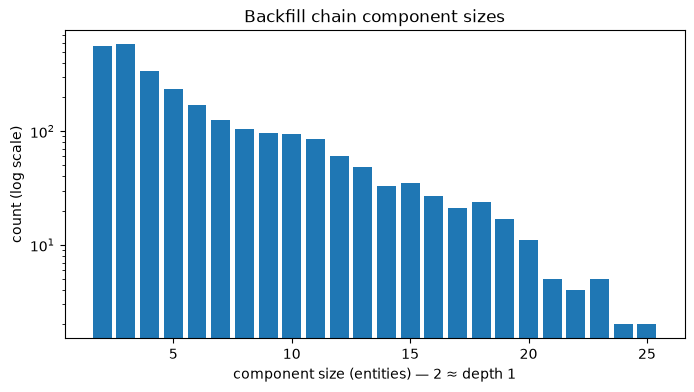

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = collections.Counter(component_sizes)
sizes = sorted(counts)
ax.bar(sizes, [counts[s] for s in sizes])
ax.set_yscale("log")
ax.set_xlabel("component size (entities) — 2 ≈ depth 1")
ax.set_ylabel("count (log scale)")
ax.set_title("Backfill chain component sizes")
plt.show()

**Reading this:** a genuinely subcritical branching process should look
like this — a sharp majority at the smallest sizes, a smoothly decaying
tail, no bimodal hump suggesting runaway growth at some threshold. If a
future change to `weightedResolve`'s own weights shifts this from a
decaying tail to something flatter or bimodal, that is a real regression
worth chasing, not just a cosmetic shift.